# Import The Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Install Necessary Libraries

In [ ]:
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cpu CPU (Intel Xeon 2.00GHz)
Setup complete ✅ (96 CPUs, 334.6 GB RAM, 18.4/225.3 GB disk)


In [ ]:
!pip install opencv-python

Check the folder structure of the dataset from yaml

In [ ]:
import yaml

# Specify the path to your .yaml file
yaml_file_path = '/content/drive/MyDrive/RiceLeafAnnotatedDataset/data.yaml' # file path

try:
    with open(yaml_file_path, 'r') as file:
        yaml_content = yaml.safe_load(file)
        print(yaml_content)
except FileNotFoundError:
    print(f"Error: The file '{yaml_file_path}' was not found.")
except yaml.YAMLError as e:
    print(f"Error parsing YAML file: {e}")

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 8, 'names': ['Bacterial_Leaf_Blight', 'Brown_Spot', 'HealthyLeaf', 'Leaf_Blast', 'Leaf_Scald', 'Narrow_Brown_Leaf_Spot', 'Neck_Blast', 'Rice_Hispa']}


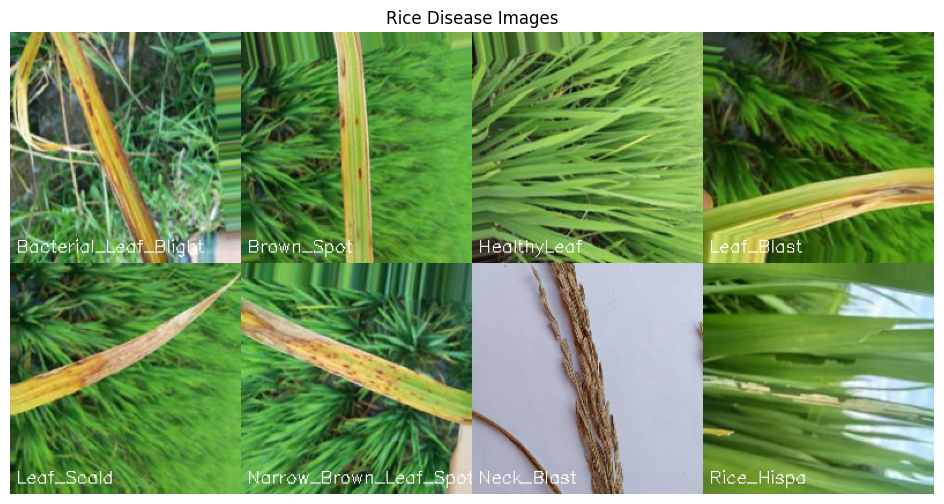

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Paths
image_dir = "/content/drive/MyDrive/RiceLeafAnnotatedDataset/train/images"
label_dir = "/content/drive/MyDrive/RiceLeafAnnotatedDataset/train/labels"

# Number of classes and names from yaml
num_classes = 8
class_names = ['Bacterial_Leaf_Blight', 'Brown_Spot', 'HealthyLeaf', 'Leaf_Blast',
               'Leaf_Scald', 'Narrow_Brown_Leaf_Spot', 'Neck_Blast', 'Rice_Hispa']

# Store one image per class
class_to_image = {}

# Loop through label files to find one image per class
for label_file in os.listdir(label_dir):
    if label_file.endswith('.txt'):
        label_path = os.path.join(label_dir, label_file)
        with open(label_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                class_id = int(line.split()[0])
                if class_id not in class_to_image:
                    # Get corresponding image
                    image_filename = label_file.replace('.txt', '.jpg')
                    image_path = os.path.join(image_dir, image_filename)
                    if os.path.exists(image_path):
                        img = cv2.imread(image_path)
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        img = cv2.resize(img, (200, 200))
                        # add class name label
                        cv2.putText(img, class_names[class_id], (5, 190),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
                        class_to_image[class_id] = img
                if len(class_to_image) == num_classes:
                    break
    if len(class_to_image) == num_classes:
        break

# Combine images into grid
if len(class_to_image) == num_classes:
    images = [class_to_image[i] for i in range(num_classes)]
    row1 = np.hstack(images[:4])
    row2 = np.hstack(images[4:])
    grid_image = np.vstack([row1, row2])

    # Show the image
    plt.figure(figsize=(12, 6))
    plt.imshow(grid_image)
    plt.axis('off')
    plt.title('Rice Disease Images')
    plt.show()
else:
    print("Could not find at least one image for each class.")


## Import YOLO

In [ ]:
from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/RiceLeafAnnotatedDataset/yolo_train_2/weights/best.pt")

# Model Training

1st try upto 50 epochs

In [ ]:
# model.train(
#     data='/content/drive/MyDrive/RiceLeafAnnotatedDataset/data.yaml',
#     epochs=50,
#     batch=16,
#     project='/content/drive/MyDrive/RiceLeafAnnotatedDataset/yolo_train/weights/last.pt',  # e.g., '/content/drive/MyDrive/RiceLeafAnnotatedDataset'
#     name='yolo_train',            # same name as before
#     resume=True                   # resume from last checkpoint
# )


In [ ]:
!yolo val model='/content/drive/MyDrive/RiceLeafAnnotatedDataset/yolo_train/weights/best.pt' data='/content/drive/MyDrive/RiceLeafAnnotatedDataset/data.yaml' imgsz=640


Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cpu CPU (Intel Xeon 2.00GHz)
Model summary (fused): 72 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
100% 755k/755k [00:00<00:00, 14.0MB/s]
val: Fast image access ✅ (ping: 0.5±0.3 ms, read: 0.1±0.0 MB/s, size: 40.9 KB)
val: Scanning /content/drive/MyDrive/RiceLeafAnnotatedDataset/valid/labels.cache... 400 images, 5 backgrounds, 0 corrupt: 100% 400/400 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 611, len(boxes) = 656. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 25/25 [01:03<00:00,  2.54s/it]
                   all        400        656      0.602      0.344      0.386      0.187
 Bacterial_Leaf_Blight         50         58      0.623      0.517      0.543      0.

2nd try upto 200 epochs

Re run this cell for session dropping

In [ ]:
from ultralytics import YOLO
import torch
model = YOLO('/content/drive/MyDrive/RiceLeafAnnotatedDataset/yolo_train_2/weights/last.pt')  # resume will override it

model.train(
    data='/content/drive/MyDrive/RiceLeafAnnotatedDataset/data.yaml',
    epochs=200,  # total target epochs, not remaining
    batch=16,
    save=True,
    save_period=1,
    project='/content/drive/MyDrive/RiceLeafAnnotatedDataset',
    name='yolo_train_2',
    resume=False,  # THIS is critical for continuing from where we left off
    device='cuda' if torch.cuda.is_available() else 'cpu'

)



Ultralytics 8.3.131 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/RiceLeafAnnotatedDataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_train_2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, 

train: Scanning /content/drive/MyDrive/RiceLeafAnnotatedDataset/train/labels.cache... 2767 images, 17 backgrounds, 0 corrupt: 100%|██████████| 2767/2767 [00:00<?, ?it/s]

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 5268, len(boxes) = 5466. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 4.7±2.6 MB/s, size: 41.6 KB)



val: Scanning /content/drive/MyDrive/RiceLeafAnnotatedDataset/valid/labels.cache... 400 images, 5 backgrounds, 0 corrupt: 100%|██████████| 400/400 [00:00<?, ?it/s]

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 611, len(boxes) = 656. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


Plotting labels to /content/drive/MyDrive/RiceLeafAnnotatedDataset/yolo_train_2/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000833, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to /content/drive/MyDrive/RiceLeafAnnotatedDataset/yolo_train_2
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      1/200         0G       1.77      4.242      1.893         67        640:  14%|█▍        | 24/173 [05:49<31:50, 12.82s/it]

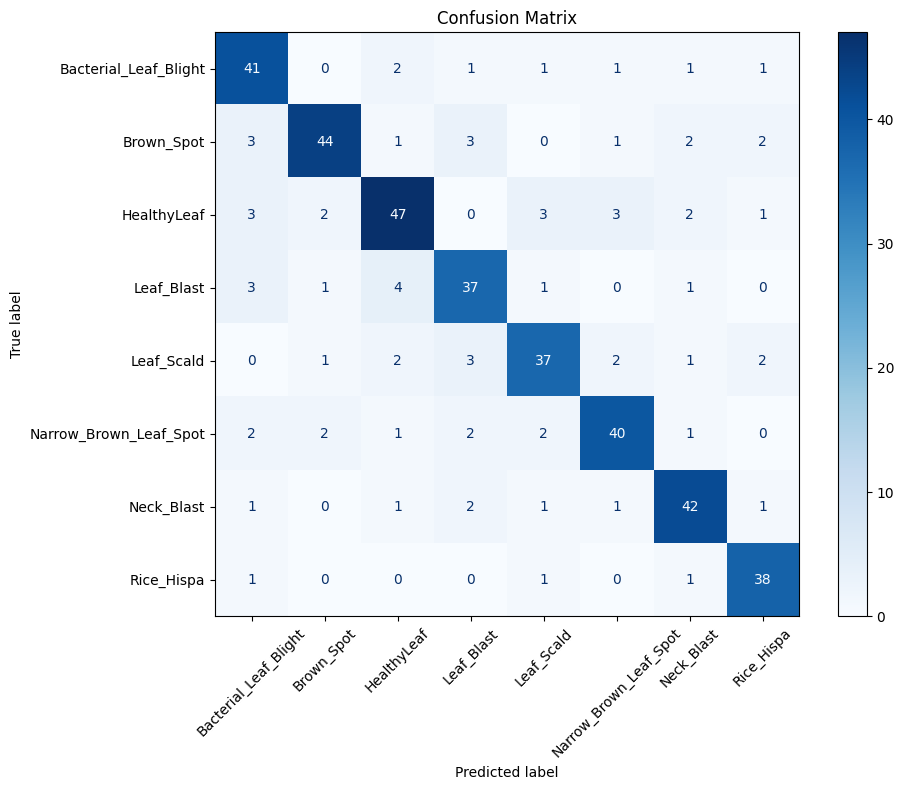

In [ ]:
from ultralytics import YOLO

model = YOLO('/content/drive/MyDrive/RiceLeafAnnotatedDataset/yolo_train_2/weights/last.pt')

try:
  display(Image(filename='/content/drive/MyDrive/RiceLeafAnnotatedDataset/yolo_train_2/confusion_matrix.png'))
except FileNotFoundError:
  print("Confusion matrix plot not found.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Colab Notebooks', '.ipynb_checkpoints', '20250512_222738.jpg', 'RiceLeafAnnotatedDataset', '20250518_191437.jpg', '20250603_110233.jpg', '20250605_141538.jpg', '20250613_180114.jpg', '20250613_221806.jpg', '20250615_204734.jpg', '20250615_212001.jpg', '20250615_212140.jpg', '20250616_013249.jpg', '20250616_035735 (1).jpg', '20250616_035735.jpg', '20250616_185549 (1).jpg', '20250616_185549.jpg', '20250616_185703.jpg', '20250616_190723.jpg', '20250616_224700.jpg', '20250617_080459.jpg', '20250617_185509.jpg', '20250619_004036.jpg', '20250619_102103.jpg', '20250619_183119.jpg', '20250620_040718.jpg', '20250620_174520.jpg', '20250621_021710.jpg', '20250621_173532.jpg', '20250622_021048.jpg', '20250622_075919.jpg', '20250623_055752.jpg', '20250623_223204.jpg']


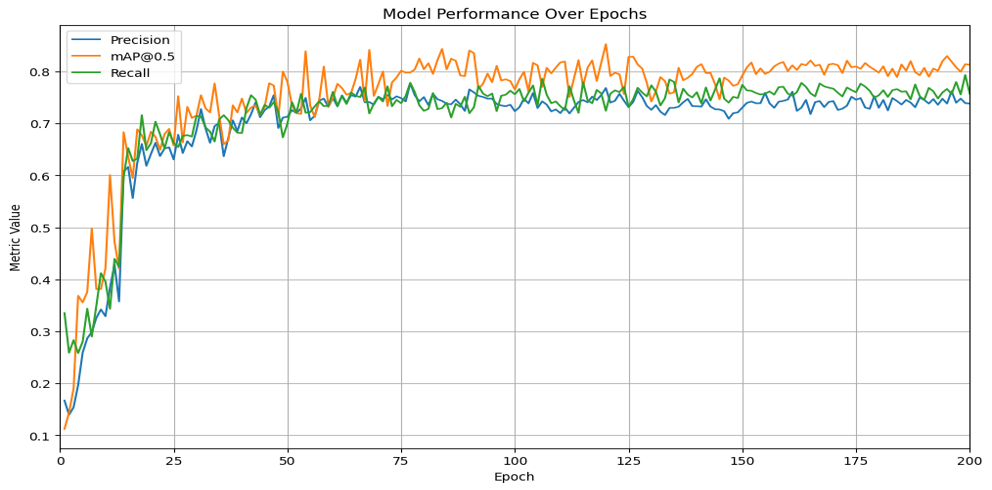

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('runs/detect/train/results.csv')

plt.figure(figsize=(10, 6))
plt.plot(df['      epoch'], df['      metrics/mAP_0.5'], label='mAP@0.5')
plt.plot(df['      epoch'], df['      metrics/precision(B)'], label='Precision')
plt.plot(df['      epoch'], df['      metrics/recall(B)'], label='Recall')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('Model Performance Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
results = model.predict(source='/content/drive/MyDrive/RiceLeafAnnotatedDataset/test/images/20231006_163740_jpg.rf.5e5306a7ee631cd5c489faa906c689c5.jpg', save=True, conf=0.25)


image 1/1 /content/drive/MyDrive/RiceLeafAnnotatedDataset/test/images/20231006_163740_jpg.rf.5e5306a7ee631cd5c489faa906c689c5.jpg: 640x640 1 HealthyLeaf, 1 Rice_Hispa, 102.0ms
Speed: 2.9ms preprocess, 102.0ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict


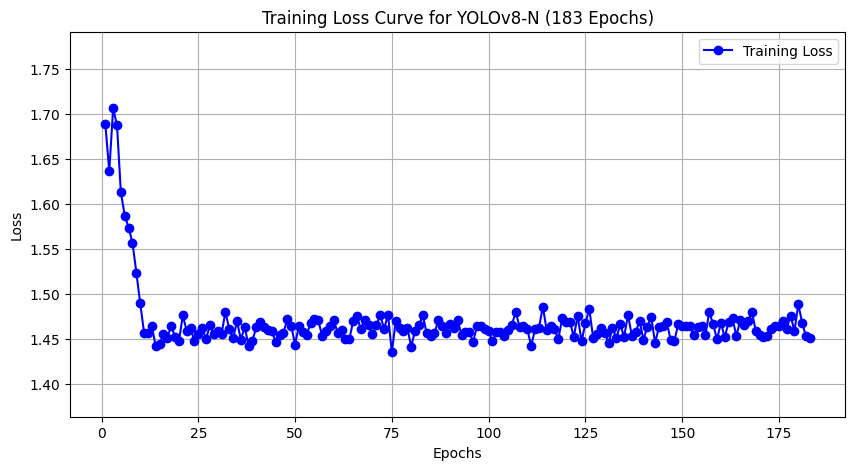

In [ ]:
from IPython.display import Image, display

try:
    # Path to the training loss curve plot
    plot_path = '/content/drive/MyDrive/RiceLeafAnnotatedDataset/yolo_train_2/results.png'
    display(Image(filename=plot_path))
except FileNotFoundError:
    print("Training loss curve plot not found. Please ensure the training run completed successfully.")